In [1]:
%reset -f
import sympy
import numpy
import scipy
import inspect
import textwrap
import ast
import random
import IPython
import IPython as ipy
import re as regex
import math
import json
import platform
import requests
import markdown
import itertools

import matplotlib
import matplotlib.pyplot as plt

def execexpr(script, globals=globals(), locals=locals()):
    stmts = list(ast.iter_child_nodes(ast.parse(script)))
    if not stmts:
        return None
    if isinstance(stmts[-1], ast.Expr):
        if len(stmts) > 1:
            exec(compile(ast.Module(body=stmts[:-1],type_ignores=[]), filename="<ast>", mode="exec"), globals, locals)
        return eval(compile(ast.Expression(body=stmts[-1].value), filename="<ast>", mode="eval"), globals, locals)
    else:
        return exec(script, globals, locals)

def using(*modules):
    def decorator(func):
        frame = inspect.currentframe()
        try:
            return execexpr(f'''{textwrap.dedent(''.join(inspect.getsourcelines(func)[0][1:]))}{func.__name__}()''', globals={**{k: v for module in modules for [k, v] in module.__dict__.items()}, **frame.f_back.f_locals, **globals()})
        finally:
            del frame
    return decorator

In [2]:
exec(__import__('requests').get('https://raw.githubusercontent.com/SteveBeeblebrox/md/refs/heads/main/md').text)

In [3]:
import numpy, scipy
class sparse_mtx_builder:
    def __init__(self, rows: int, cols: int | None = None, data: tuple[list[int], list[int], list[int]] = ([], [], []), /, dtype=lambda v: v):
        self.rows = rows
        self.cols = cols if cols is not None else rows
        self.data = data
        self.dtype = dtype
    def __getitem__(self, key: tuple[int, int]):
        self._validate(*(key:=self._wrap(*key)))
        return (lambda index: self.data[2][index] if index != None else 0)(self._get_index(*key))
    def __setitem__(self, key: tuple[int, int], value):
        self._validate(*(key:=self._wrap(*key)))
        value = self.dtype(value)
        index = self._get_index(*key)
        if index != None:
            if value == 0:
                del self[key]
            else:
                self.data[2][index] = value
        elif value != 0:
            self.data[0].append(key[0])
            self.data[1].append(key[1])
            self.data[2].append(value)
    def __delitem__(self, key: tuple[int, int]):
        self._validate(*(key:=self._wrap(*key)))
        (lambda index: [l.pop(index) for l in self.data if index is not None])(self._get_index(*key))
    def __repr__(self) -> str:
        return f'{type(self).__name__}({self.rows}, {self.cols}, {self.data}, dtype={self.dtype})'
    def __len__(self) -> int:
        return len(self.data[0])
    def _get_index(self, i: int, j: int) -> int:
        try:
            return [*zip(self.data[0], self.data[1])].index((i, j))
        except ValueError:
            return None
    def _validate(self, i: int, j: int):
        if i >= self.rows or i < 0 or j >= self.cols or j < 0:
            raise IndexError(f'Index {(i,j)} out of range for {self.rows}x{self.cols} matrix')
    def _wrap(self, i: int, j: int) -> tuple[int, int]:
        return (i % self.rows if i < 0 else i, j % self.cols if j < 0 else j)
    def __iter__(self):
        for i in range(self.rows):
            for j in range(self.cols):
                yield (i, j), self[i, j]
    def set_diag(self, value, k: int = 0):
        for i in range(self.rows):
            j = i + k
            if 0 <= j < self.cols:
                self[i, j] = value
    def to_coo(self) -> scipy.sparse.coo_array:
        return scipy.sparse.coo_array((self.data[2], (self.data[0], self.data[1])), shape=(self.rows, self.cols))
    def to_csr(self) -> scipy.sparse.csr_array:
        return self.to_coo().tocsr()
    def to_csc(self) -> scipy.sparse.csc_array:
        return self.to_coo().tocsc()
    def to_lil(self) -> scipy.sparse.lil_array:
        return self.to_coo().tolil()
    def to_dia(self) -> scipy.sparse.dia_array:
        return self.to_coo().todia()
    def to_dok(self) -> scipy.sparse.dok_array:
        return self.to_coo().todok()
    def to_dense(self) -> numpy.ndarray:
        return self.to_coo().todense()
    @staticmethod
    def from_coo(coo: scipy.sparse.coo_array):
        if len(coo.shape) != 2:
            raise ValueError('COO array must be 2D')
        return sparse_mtx_builder(*coo.shape, (list(coo.row), list(coo.col), list(coo.data)), dtype=coo.dtype)
    @staticmethod
    def from_csr(csr: scipy.sparse.csr_array):
        return sparse_mtx_builder.from_coo(csr.tocoo())
    @staticmethod
    def from_csc(csc: scipy.sparse.csc_array):
        return sparse_mtx_builder.from_coo(csc.tocoo())
    @staticmethod
    def from_lil(lil: scipy.sparse.lil_array):
        return sparse_mtx_builder.from_coo(lil.tocoo())
    @staticmethod
    def from_dia(dia: scipy.sparse.dia_array):
        return sparse_mtx_builder.from_coo(dia.tocoo())
    @staticmethod
    def from_dok(dok: scipy.sparse.dok_array):
        return sparse_mtx_builder.from_coo(dok.tocoo())

In [131]:
def plot_error(f, /, *, N_min: int = 5, N_max: int = 100, title: str = "$N$ vs. Relative Error", aspect: str = 'equal', file: str | None = None):
  plt.figure()
  N = numpy.arange(N_min,N_max, 1)
  for p in [2, numpy.inf]:
    @numpy.vectorize
    def test(N):
      x, a, n = f(N)
      return numpy.linalg.norm(a - n, ord=p)/numpy.linalg.norm(a, ord=p)
    t = test(N)
    m, b = numpy.polyfit(numpy.log(N), numpy.log(t), 1)
    plt.loglog(N, t, label=rf"$p={r'\infty' if p == numpy.inf else p}$ (Slope ${m:.03f}$)")

  plt.legend()
  plt.margins(0)
  plt.xticks([N_min,10,N_max])
  plt.yticks([0.1,0.01])
  plt.xlabel("$N$")
  plt.ylabel(r"Error")
  plt.title(title)
  plt.grid(True, which='both')
  if aspect != 'auto':
    plt.gca().set_aspect(aspect=aspect)

  if file is not None:
    plt.savefig(file)

def fig(name: str) -> str:
  plt.savefig(name)
  return f'![{name}]({name})'

In [5]:
%md # Numerical PDEs Homework #0
%md Trin Wasinger | 2026-09-17
%md
%md ---

# Numerical PDEs Homework #0

Trin Wasinger | 2026-09-17

---

In [ ]:
%md ## Problem #1

## Problem #1

![problem1.1.png](problem1.1.png)

![problem1.2.png](problem1.2.png)

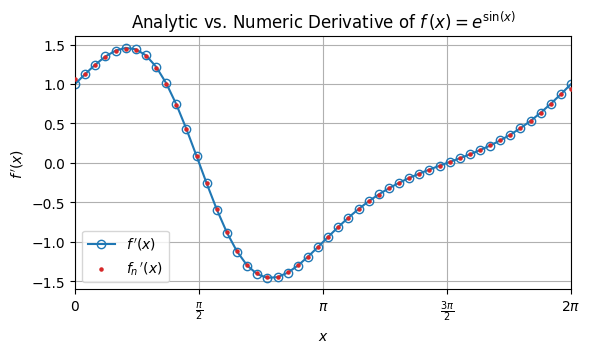

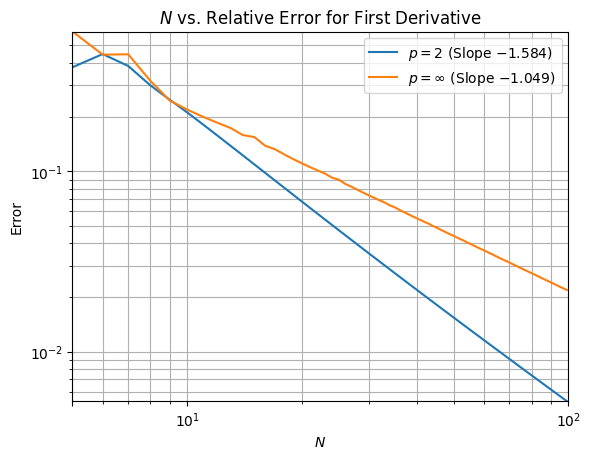

In [6]:
@using(sympy)
def fprime():
  x = Symbol('x')
  return diff(exp(sin(x)), x)

@using(numpy)
def _():
  def doit(N=50):
    start,stop = 0,2*pi
    h = (stop - start)/(N - 1)
    x = linspace(start, stop, N)
    f = exp(sin(x))
    fprime_n = [
        (f[1] - f[0])/h,
        *(f[2:] - f[:-2])/(2*h),
        (f[-1] - f[-2])/h
    ]

    fprime_a = sympy.lambdify(sympy.Symbol('x'), fprime, modules='numpy')(x)
    return x, fprime_a, fprime_n

  ######

  x, fprime_a, fprime_n = doit()
  plt.plot(x, fprime_a,label=r"$f\,'(x)$", markerfacecolor='none', marker='o')
  plt.scatter(x,fprime_n,label=r"$f_n\,'(x)$", color='tab:red', zorder=99, s=5)

  plt.legend()
  plt.margins(x=0)
  plt.xticks([0,pi/2,pi,3*pi/2,2*pi], [r"$0$",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3\pi}{2}$",r"$2\pi$"])
  plt.xlabel("$x$")
  plt.ylabel(r"$f\,'(x)$")
  plt.title(r'Analytic vs. Numeric Derivative of $f\,(x) = e^{\sin(x)}$')
  plt.grid()
  plt.gca().set_aspect(aspect='equal')

  %md {fig('problem1.1.png')}

  plot_error(doit,title='$N$ vs. Relative Error for First Derivative', aspect='auto')

  %md {fig('problem1.2.png')}

## Problem #2

![problem2.1.png](problem2.1.png)

![problem2.2.png](problem2.2.png)

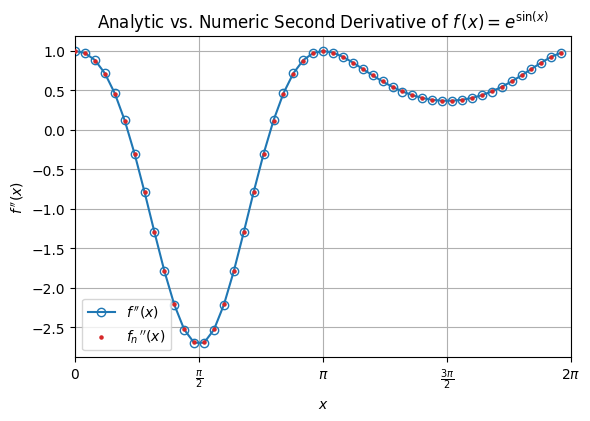

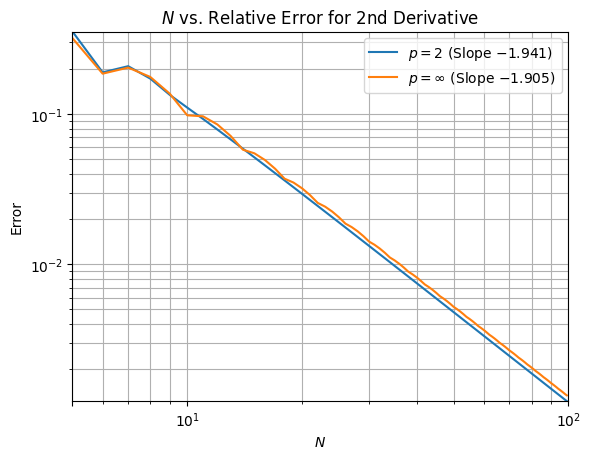

In [7]:
%md ## Problem #2
@using(sympy)
def fprime2():
  x = Symbol('x')
  return diff(diff(exp(sin(x)), x), x)

@using(numpy)
def _():
  def doit(N=50):
    start,stop = 0,2*pi
    h = (stop - start)/(N)                       # vvvvvvvv
    x = linspace(start, stop, N, endpoint=False) # don't include duplicate ends for periodic boundaries
    f = exp(sin(x))
    fprime2_n = (roll(f, -1) - 2*f + roll(f, +1))/h**2 # Note, signs in roll are opposite original formula!

    fprime2_a = sympy.lambdify(sympy.Symbol('x'), fprime2, modules='numpy')(x)
    return x, fprime2_a, fprime2_n

  ######

  x, fprime2_a, fprime2_n = doit()
  plt.plot(x, fprime2_a,label=r"$f\,''(x)$", markerfacecolor='none', marker='o')
  plt.scatter(x,fprime2_n,label=r"$f_n\,''(x)$", color='tab:red', zorder=99, s=5)

  plt.legend()
  plt.margins(x=0)
  plt.xticks([0,pi/2,pi,3*pi/2,2*pi], [r"$0$",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3\pi}{2}$",r"$2\pi$"])
  plt.xlabel("$x$")
  plt.ylabel(r"$f\,''(x)$")
  plt.title(r'Analytic vs. Numeric Second Derivative of $f\,(x) = e^{\sin(x)}$')
  plt.grid()
  plt.gca().set_aspect(aspect='equal')

  %md {fig('problem2.1.png')}

  plot_error(doit, title="$N$ vs. Relative Error for 2nd Derivative", aspect='auto')

  %md {fig('problem2.2.png')}

In [8]:
def plot_approximation(f,N: int, /, *,
    aspect: str = 'equal',
    file: str | None = None,
    var: str = "x",
    func: str = r"f",
    title: str = 'Analytic vs. Numeric Solution',
    domain = None
  ):

  plt.figure()

  x, a, n = f(N)
  plt.plot(x, a, label=rf"${func}\,({var})$", markerfacecolor='none', marker='o')
  plt.scatter(x, n, label=rf"${regex.sub(r'^(\w+)', r'\1_n', func)}\,({var})$", color='tab:red', zorder=99, s=5)

  plt.legend()
  plt.margins(x=0)
  if domain is not None:
    plt.xticks([sympy.N(v) for v in domain], [sympy.latex(v) for v in domain])
  plt.xlabel(f"${var}$")
  plt.ylabel(rf"${func}\,({var})$")
  plt.title(title)
  plt.grid()
  if aspect != 'auto':
    plt.gca().set_aspect(aspect=aspect)
  if file is not None:
    plt.savefig(file)

## Problem #3

![problem3.1.png](problem3.1.png)

![problem3.2.png](problem3.2.png)

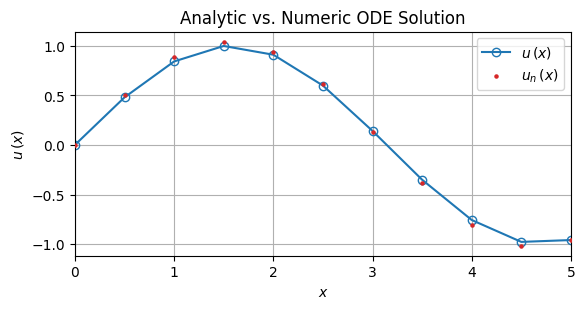

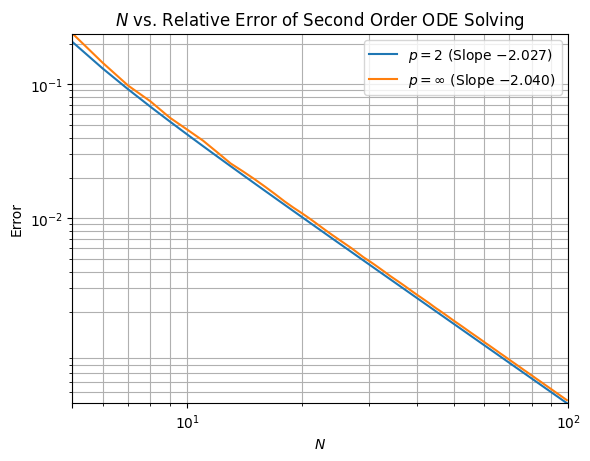

In [9]:
%md ## Problem #3
#            u_{i-1} - 2*u_{i} + u_{i+1}
# u''_{i} = -----------------------------
#                       h**2

#           u_{i+1} - u_{i-1}
# u'_{i} = --------------------
#                  2h

#          u_{i-1} - 2*u_{i} + u_{i+1}             u_{i+1} - u_{i-1}
# f_{i} = ---------------------------- + sin(x_i) -------------------- + u_i
#                    h**2                                  2h

# @using(sympy)
# def _():
#     uminus,u,uplus,h,x=Symbol('u_-'),Symbol('u'),Symbol('u_+'),Symbol('h'),Symbol('x')
#     f = (uminus - 2*u + uplus)/h**2 + sin(x)*(uplus - uminus)/(2*h) + u
#     # display(gcd_terms(f))

# f_{i} = u_{i} (1 - 2/h**2)
#       + u_{i+1} (1/h**2 + sin(x)/(2h))
#       + u_{i-1} (1/h**2 - sin(x)/(2h))

@using(numpy)
def _():
    def solve(N = 5):
        x0,xN=0,5
        h=(xN-x0)/N

        # Dirichlet boundaries
        u_0 = sin(0)
        u_N = sin(5)

        x = linspace(x0, xN, N+1)
        rhs = f = cos(x)*sin(x)

        l = 1/h**2 - sin(x)/(2*h)
        d = [1 - 2/h**2]*len(x)
        r = 1/h**2 + sin(x)/(2*h)

        # treat boundaries as unknowns for simplicity
        l[0] = r[0] = 0
        d[0] = 1

        l[-1] = r[-1] = 0
        d[-1] = 1

        rhs[0] = u_0
        rhs[-1] = u_N

        M = scipy.sparse.diags(
              [l[1:], d, r[:-1]],
              offsets=[-1, 0, 1]
        ).tocsc()

        return x, sin(x), scipy.sparse.linalg.spsolve(M, rhs)

    plot_approximation(solve, 10, func='u', title=r'Analytic vs. Numeric ODE Solution')
    %md {fig('problem3.1.png')}
    plot_error(solve, aspect='auto', title="$N$ vs. Relative Error of Second Order ODE Solving")
    %md {fig('problem3.2.png')}


## Problem #4

> NOTE: My editor's AI autocomplete suggested a large portion of the boundary implementation (completly unprompted) as I started writing the first loop.

> It was more or less exactly what I was going to type anyways, but I am not sure how I feel about it. I've since found the setting to turn the AI autocomplete off.

Range: [-1, 1]


![problem4.1.png](problem4.1.png)

![problem4.2.png](problem4.2.png)

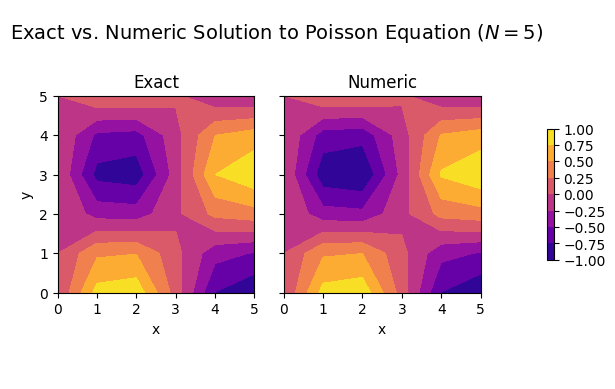

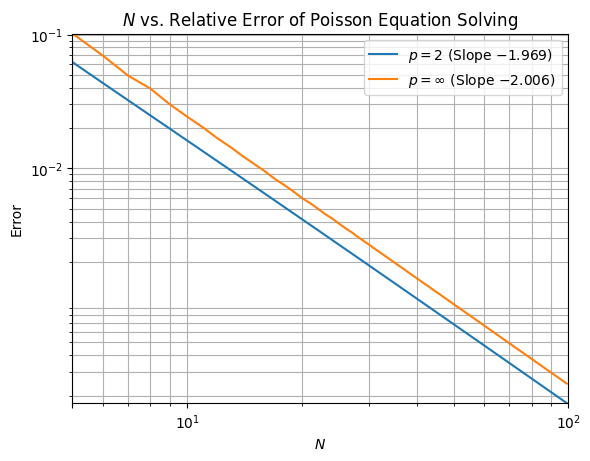

In [138]:
%md ## Problem #4
%md > NOTE: My editor's AI autocomplete suggested a large portion of the boundary implementation (completly unprompted) as I started writing the first loop.
%md > It was more or less exactly what I was going to type anyways, but I am not sure how I feel about it. I've since found the setting to turn the AI autocomplete off.
@lambda _:_()
def _():
  def solve(Nx=5,Ny=5,x0=0,xN=5,y0=0,yN=5):

    dx = (xN - x0)/Nx
    dy = (yN - y0)/Ny

    x = numpy.linspace(x0, xN, Nx + 1)
    y = numpy.linspace(y0, yN, Ny + 1)
    nx, ny = Nx + 1, Ny + 1

    X, Y = numpy.meshgrid(x, y) # k = i + j*nx

    u_a = lambda x,y: numpy.sin(x)*numpy.cos(y)
    f = -2*numpy.sin(X)*numpy.cos(Y) # = \nabla^2 (sin(x)cos(y)) by MMS
    rhs = f.flatten()

    Dx = scipy.sparse.diags([1, -2, 1], [-1, 0, 1], shape=(nx, ny))/dx**2
    Dy = scipy.sparse.diags([1, -2, 1], [-1, 0, 1], shape=(ny, nx))/dy**2

    L = (scipy.sparse.kron(scipy.sparse.eye(ny), Dx) + scipy.sparse.kron(Dy, scipy.sparse.eye(nx))).tolil()

    # display(L.todense())

    # Boundary conditions
    for j in range(ny):
      k = 0 + j*nx
      L.rows[k] = [k]
      L.data[k] = [1]
      rhs[k] = u_a(x0, y[j])

      k = (nx - 1) + j*nx
      L.rows[k] = [k]
      L.data[k] = [1]
      rhs[k] = u_a(xN, y[j])

    for i in range(nx):
      k = i + 0*nx
      L.rows[k] = [k]
      L.data[k] = [1]
      rhs[k] = u_a(x[i], y0)

      k = i + (ny - 1)*nx
      L.rows[k] = [k]
      L.data[k] = [1]
      rhs[k] = u_a(x[i], yN)

    # plt.spy(L)


    phi = scipy.sparse.linalg.spsolve(L.tocsr(), rhs)
    return X, Y, u_a(X, Y), phi.reshape(ny, nx)


  N = 5
  figure,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,width_ratios=[0.45,0.45,0.1])
  X,Y,u_a,u_n = solve(N, N)

  lower=math.floor(min(*u_a.flatten(), *u_n.flatten()))
  upper=math.ceil(max(*u_a.flatten(), *u_n.flatten()))
  print(f'Range: [{lower}, {upper}]')

  ax1.contourf(X,Y,u_a,vmin=lower,vmax=upper,cmap='plasma')
  ax1.set_title("Exact")
  ax1.set_aspect(aspect='equal')
  ax1.set_xlabel('x')
  ax1.set_ylabel('y')
  ax1.set_xticks(range(0,6))
  ax1.set_yticks(range(0,6))

  cf = ax2.contourf(X,Y,u_n,vmin=lower,vmax=upper,cmap='plasma')
  ax2.set_title("Numeric")
  ax2.set_aspect(aspect='equal')
  ax2.set_xlabel('x')
  ax2.set_xticks(range(0,6))

  figure.colorbar(cf, ax=ax3)
  ax3.axis('off')

  plt.title(rf"Exact vs. Numeric Solution to Poisson Equation ($N={N}$)" + '\u00a0', loc='right', y=0.9, fontsize=14)
  %md {fig('problem4.1.png')}

  plot_error(lambda N: [[], *[a.flatten() for a in solve(N, N)[2:]]], aspect='auto',  title="$N$ vs. Relative Error of Poisson Equation Solving")
  %md {fig('problem4.2.png')}

In [130]:
!zip archive.zip *.png

updating: problem1.1.png (deflated 8%)
updating: problem1.2.png (deflated 7%)
updating: problem2.1.png (deflated 7%)
updating: problem2.2.png (deflated 8%)
updating: problem3.1.png (deflated 10%)
updating: problem3.2.png (deflated 8%)
updating: problem4.2.png (deflated 7%)
